# Where does a mix's risk sit, what range is its value in, and what does paying in regularly lead to?

**In short.** In a mixed portfolio the share of the money and the share of the risk
are very different things: a small holding that moves a lot can carry most of the
risk, and cash carries none. The range of values ahead is drawn from real past days.
Past ranges held a little more often than they said, so they are slightly too wide,
and they have **not** beaten a plain bell curve: the counts are in step 4. Paying in bit by bit is a way of having
less at risk early on. It is not a way of getting a better price.

| Step | What it does | Code | Screen in the app |
|---|---|---|---|
| 1 | Measures how much each holding moves, and how they move together | `radar.models.portfolio` | Portfolio, Where the risk sits |
| 2 | Splits the mix's risk between its holdings | `radar.models.portfolio` | Portfolio, Where the risk sits |
| 3 | Draws the range of values ahead | `radar.models.portfolio_simulation` | Portfolio, The range ahead |
| 4 | Counts how often past ranges held, beside simpler methods | `radar.models.portfolio_simulation` | Portfolio, The range ahead |
| 5 | Plays out a plan of regular purchases | `radar.models.regular_buying` | Portfolio, Paying in |

**The portfolio here is made up**: 10,000 dollars, 30% US stocks, 15% gold, 15%
Bitcoin, the rest cash.

Rebuild with `uv run python backend/scripts/build_notebooks.py 05_portfolio_and_paying_in`.

In [1]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.covariance import LedoitWolf

from radar.db.session import make_engine, session_scope
from radar.models import portfolio as risk
from radar.models import portfolio_simulation as ahead
from radar.models import regular_buying as paying_in
from radar.models import simulator
from radar.notebooks import ACCENT, BAD, INK, MUTED, use_style
from radar.pipelines.datasets import build_mixed_panel
from radar.universe import get_universe

use_style()
engine, universe = make_engine(), get_universe()
OF_KIND = {asset.kind: asset for asset in universe.primary}
VALUE = 10_000.0
SHARES = {"stocks": 0.30, "gold": 0.15, "bitcoin": 0.15}  # the rest, 40%, is cash
COLOURS = {"stocks": ACCENT, "gold": "#c9952b", "bitcoin": "#e8843c"}
symbols = [OF_KIND[kind].symbol for kind in SHARES]
names = [OF_KIND[kind].name.split(" (")[0] for kind in SHARES]
colours = list(COLOURS.values())
weights = np.array(list(SHARES.values()))

with session_scope(engine) as session:
    panel = build_mixed_panel(session, universe)

# Daily returns on days when the US stock market was open. Bitcoin and gold trade every
# day, so their weekend move is folded into Monday: every column describes the same days.
returns = panel.returns[symbols].dropna()
matrix = returns.to_numpy()
print(f"{len(returns):,} trading days, {returns.index[0].date()} to {returns.index[-1].date()}")

1,445 trading days, 2021-01-05 to 2026-10-06


## Step 1. How much each holding moves, and how they move together

Two things decide how much a mix moves: how much each holding moves on its own, and
whether they move together. Measured straight from the days, some of what looks like
a relationship is luck, so the measured table is pulled part of the way towards a
plain one (Ledoit-Wolf shrinkage). How far is worked out from the data: a lot with
many holdings and few days, hardly at all with few holdings and many days.

pulled 0.8% of the way towards the plain table


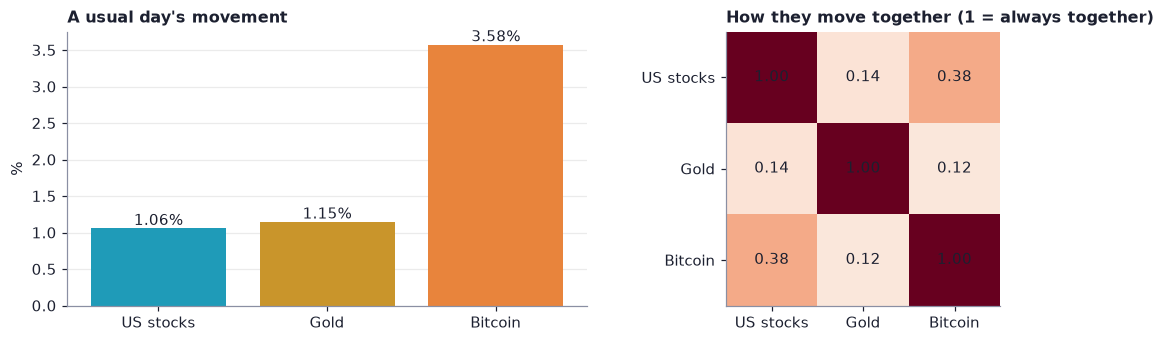

In [2]:
cov = risk.covariance(returns)
spread = np.sqrt(np.diag(cov))
pulled = LedoitWolf().fit(matrix).shrinkage_
together = cov / np.outer(spread, spread)

fig, (left, right) = plt.subplots(1, 2, figsize=(10, 3.2), gridspec_kw={"width_ratios": [1.2, 1]})
left.bar(names, spread * 100, color=colours)
for place, value in enumerate(spread * 100):
    left.text(place, value, f"{value:.2f}%", ha="center", va="bottom")
left.set(title="A usual day's movement", ylabel="%")
left.grid(axis="x", visible=False)
right.imshow(together, vmin=-1, vmax=1, cmap="RdBu_r")
right.set_xticks(range(len(names)), names)
right.set_yticks(range(len(names)), names)
for row in range(len(names)):
    for column in range(len(names)):
        right.text(column, row, f"{together[row, column]:.2f}", ha="center", va="center")
right.set(title="How they move together (1 = always together)")
right.grid(False)
fig.tight_layout()
print(f"pulled {pulled:.1%} of the way towards the plain table")

With three holdings and this many days the pull is small: the direct measurement is
already good. A bigger source of doubt is that **the relationships themselves
change**. Below, how closely Bitcoin moved with US stocks, measured one year at a time.

lowest 0.16, highest 0.54


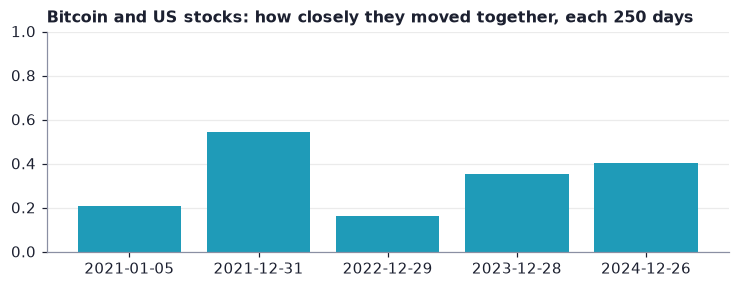

In [3]:
a, b = list(SHARES).index("stocks"), list(SHARES).index("bitcoin")
rows = []
for start in range(0, len(returns) - 250 + 1, 250):
    year = returns.iloc[start : start + 250]
    table = LedoitWolf().fit(year.to_numpy()).covariance_
    rows.append({"from": year.index[0].date(), "together": table[a, b] / np.sqrt(table[a, a] * table[b, b])})
by_year = pd.DataFrame(rows).set_index("from")
fig, ax = plt.subplots(figsize=(8, 2.6))
ax.bar([str(day) for day in by_year.index], by_year["together"], color=ACCENT)
ax.set(title="Bitcoin and US stocks: how closely they moved together, each 250 days", ylim=(0, 1))
ax.grid(axis="x", visible=False)
print(f"lowest {by_year['together'].min():.2f}, highest {by_year['together'].max():.2f}")

No single number for "how they move together" is right for every year, which is why
every figure on the Portfolio screen states the days it was measured on.

## Step 2. Share of the money against share of the risk

A holding's **share of the risk** answers: of all the mix's movement, how much comes
from this holding? It depends on its size, how much it moves, and how much it moves
with the others. The shares add up to exactly 100%.

,"share of the money, %","share of the risk, %"
US stocks,30.00,29.70
Gold,15.00,8.20
Bitcoin,15.00,62.10
Cash,40.00,0.00


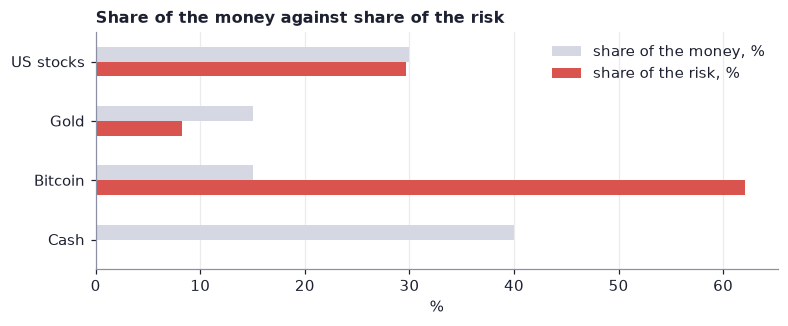

In [4]:
shares = risk.risk_shares(weights, cov)
assert abs(shares.sum() - 1.0) < 1e-9
split = pd.DataFrame(
    {"share of the money, %": [*weights * 100, (1 - weights.sum()) * 100], "share of the risk, %": [*shares * 100, 0.0]},
    index=[*names, "Cash"],
)
ax = split.plot.barh(color=["#d5d8e2", BAD], figsize=(8, 2.8))
ax.set(title="Share of the money against share of the risk", xlabel="%", ylabel="")
ax.invert_yaxis()
ax.grid(axis="y", visible=False)
split.round(1)

In [5]:
day = float(np.sqrt(weights @ cov @ weights))
biggest = split["share of the risk, %"].idxmax()
print(f"largest share of the risk: {biggest}, {split.loc[biggest, 'share of the risk, %']:.0f}% of it on {split.loc[biggest, 'share of the money, %']:.0f}% of the money")
print(f"a usual day for the mix:         {day:.2%}  (${day * VALUE:,.0f})")
print(f"if everything moved together:    {float(weights @ spread):.2%}")
print(f"US stocks alone:                 {spread[a]:.2%}")

largest share of the risk: Bitcoin, 62% of it on 15% of the money
a usual day for the mix:         0.76%  ($76)
if everything moved together:    1.03%
US stocks alone:                 1.06%


That gap between the two bars is the single most useful fact about a mixed
portfolio, and it is what the Portfolio screen opens on.

## Step 3. The range of values ahead

A simulated future is built from real past days. A random past day is picked and the
**10 trading days** from it are taken, for every holding at once; then another 10,
and another, until the future is long enough. Nothing is rebalanced and cash does not
move. That is done 10,000 times.

Whole days for every holding at once, because on a day stocks fell hard, Bitcoin
usually fell too. Runs of days, because rough days come in stretches: the chart shows
how strongly the size of one day's movement is tied to the size of later days'.

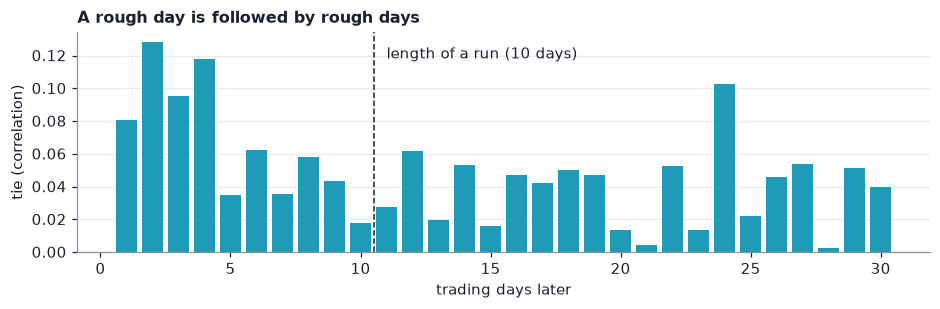

In [6]:
size = risk.mix_returns(returns, weights).abs()
later = range(1, 31)
fig, ax = plt.subplots(figsize=(10, 2.6))
ax.bar(later, [size.autocorr(lag) for lag in later], color=ACCENT)
ax.axvline(ahead.BLOCK + 0.5, color=INK, ls="--", lw=1)
ax.text(ahead.BLOCK + 1, ax.get_ylim()[1] * 0.88, f"length of a run ({ahead.BLOCK} days)")
ax.set(title="A rough day is followed by rough days", xlabel="trading days later", ylabel="tie (correlation)")
ax.grid(axis="x", visible=False)

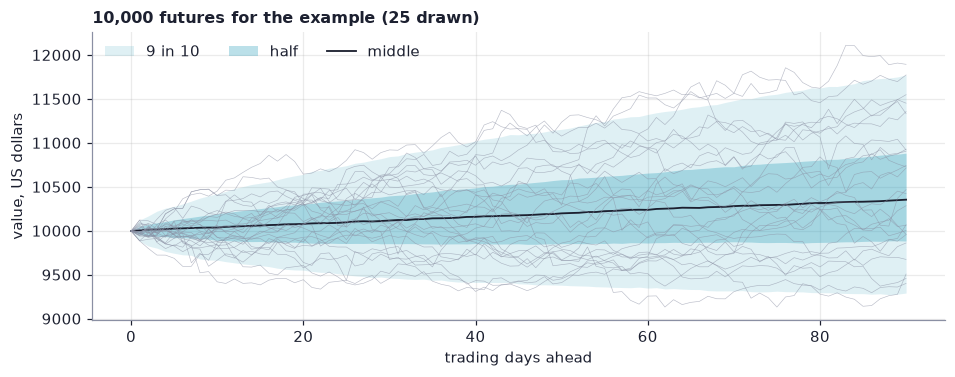

In [7]:
paths = ahead.simulate(matrix, weights, 90, seed=0)
fan = simulator.fan(paths, VALUE)
span = range(91)
fig, ax = plt.subplots(figsize=(10, 3.4))
ax.fill_between(span, fan["0.05"], fan["0.95"], color=ACCENT, alpha=0.14, lw=0, label="9 in 10")
ax.fill_between(span, fan["0.25"], fan["0.75"], color=ACCENT, alpha=0.3, lw=0, label="half")
ax.plot(span, fan["0.5"], color=INK, lw=1.2, label="middle")
for path in paths[:25]:
    ax.plot(span, [VALUE, *VALUE * np.exp(path)], color=MUTED, lw=0.4, alpha=0.6)
ax.set(title=f"{len(paths):,} futures for the example (25 drawn)", xlabel="trading days ahead", ylabel="value, US dollars")
ax.legend(loc="upper left", ncol=3);

In [8]:
stored = ahead.run(matrix, weights, VALUE)
rows = {}
for horizon in stored.horizons:
    summary = horizon.summary
    eighty = next(interval for interval in summary.intervals if interval.level == 0.8)
    down = next(chance for chance in horizon.chances if chance.change == -0.05)
    rows[f"{summary.steps} trading days"] = {
        "middle, $": summary.quantiles["0.5"],
        "8 in 10 end above, $": eighty.low,
        "8 in 10 end below, $": eighty.high,
        "usual deepest dip, %": summary.expected_worst_drawdown * 100,
        "ends 5% down, % chance": down.ends_beyond * 100,
        "is 5% down at some point, % chance": down.touches * 100,
    }
pd.DataFrame(rows).T

,"middle, $","8 in 10 end above, $","8 in 10 end below, $","usual deepest dip, %","ends 5% down, % chance","is 5% down at some point, % chance"
30 trading days,"10,119.39","9,607.46","10,666.28",-3.69,5.93,11.54
90 trading days,"10,356.61","9,499.57","11,435.25",-6.54,10.01,26.47


The last two columns answer different questions. Ending 5% down is rarer than being
5% down *at some point on the way*, because some dips recover. The app lets the
reader pick any size of change and shows both.

## Step 4. Did past ranges hold?

Stand at a past date. Draw a 30-day range **from the days before it only**. See what
the portfolio did over the next 30 days. Move on 30 days, so no two outcomes share a
day, and repeat. An honest "80% range" holds about 8 times in 10.

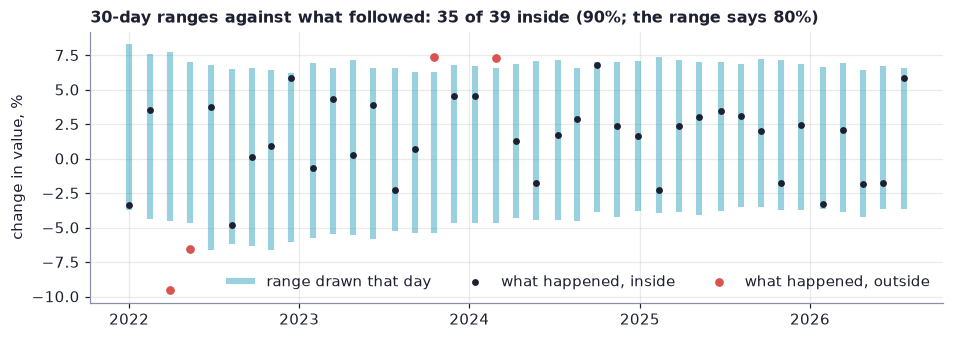

In [9]:
records = ahead.backtest(matrix, weights, 30)
dates = returns.index[[record.origin for record in records]]
low = np.array([record.bounds["0.8"][0] for record in records])
high = np.array([record.bounds["0.8"][1] for record in records])
happened = np.array([record.realised for record in records])
inside = (happened >= low) & (happened <= high)

fig, ax = plt.subplots(figsize=(10, 3.2))
ax.vlines(dates, np.expm1(low) * 100, np.expm1(high) * 100, color=ACCENT, alpha=0.45, lw=4, label="range drawn that day")
ax.scatter(dates[inside], np.expm1(happened[inside]) * 100, color=INK, s=12, zorder=3, label="what happened, inside")
ax.scatter(dates[~inside], np.expm1(happened[~inside]) * 100, color=BAD, s=22, zorder=3, label="what happened, outside")
ax.set(title=f"30-day ranges against what followed: {inside.sum()} of {len(records)} inside ({inside.mean():.0%}; the range says 80%)", ylabel="change in value, %")
ax.legend(ncol=3);

### Beside simpler methods

The same range drawn three ways, checked on the same dates: **runs of 10 days** (what
the app uses), **single days** (stretches shuffled away), and a **bell curve** with
the average and spread of the days so far. Closer to the stated figure is better; of
two that hold equally often, the narrower is more useful.

In [10]:
def held(records: list[ahead.PastRange]) -> dict[str, float]:
    row = {f"{found.level:.0%} range held, %": found.inside / found.n * 100 for found in ahead.coverage(records)}
    width = [np.expm1(record.bounds["0.8"][1]) - np.expm1(record.bounds["0.8"][0]) for record in records]
    return {**row, "cases": len(records), "width of the 80% range, %": float(np.mean(width)) * 100}


compared = {}
for horizon in ahead.HORIZONS:
    compared[(f"{horizon} days", "runs of 10 days")] = held(ahead.backtest(matrix, weights, horizon))
    compared[(f"{horizon} days", "single days")] = held(ahead.backtest(matrix, weights, horizon, block=1))
    compared[(f"{horizon} days", "bell curve")] = held(ahead.normal_backtest(matrix, weights, horizon))
compared = pd.DataFrame(compared).T
compared.round(1)

50% range held, %  80% range held, %  95% range held, %  cases  width of the 80% range, %
30 days runs of 10 days              51.30              89.70              97.40  39.00                      11.50
        single days                  51.30              89.70              97.40  39.00                      11.70
        bell curve                   48.70              89.70              97.40  39.00                      11.60
90 days runs of 10 days              53.80              76.90              92.30  13.00                      20.90
        single days                  61.50              84.60              92.30  13.00                      21.40
        bell curve                   61.50              84.60              84.60  13.00                      20.60

In [11]:
# The claim in the summary, checked: how far each method's 80% range was from 80%.
gap = (compared["80% range held, %"] - 80).abs().unstack()
print(gap.round(1).to_string())
cases = compared["cases"].unstack().iloc[:, 0]
print("\none case is worth this many points:", {key: round(100 / count, 1) for key, count in cases.items()})

         bell curve  runs of 10 days  single days
30 days        9.70             9.70         9.70
90 days        4.60             3.10         4.60

one case is worth this many points: {'30 days': 2.6, '90 days': 7.7}


**Read the gaps beside what one case is worth.** Where the methods differ by less
than a case or two, they cannot be told apart, and on this mix and these years that
is the result: joining runs of real days is not measurably more accurate than a bell
curve. The app states the bell curve's record beside the simulation's and does not
claim otherwise.

The simulation is used for what else it gives. It can only produce days that really
happened, the worst ones included, for all holdings together. And it gives what a
formula for the end point cannot: the dips on the way, and the chance of touching a
level before the end.

### Does the length of a run matter?

In [12]:
pd.DataFrame(
    {f"runs of {block}": held(ahead.backtest(matrix, weights, 30, block=block)) for block in (1, 5, 10, 20)}
).T.round(1)

,"50% range held, %","80% range held, %","95% range held, %",cases,"width of the 80% range, %"
runs of 1,51.30,89.70,97.40,39.00,11.70
runs of 5,48.70,89.70,97.40,39.00,11.30
runs of 10,51.30,89.70,97.40,39.00,11.50
runs of 20,51.30,89.70,97.40,39.00,11.70


The one number picked by judgement barely moves the answer.

### Later days cannot change an earlier range

In [13]:
tampered = matrix.copy()
cut = len(matrix) // 2
tampered[cut:] = 0.5
again = ahead.backtest(tampered, weights, 30)
same = [one.bounds == other.bounds for one, other in zip(records, again) if one.origin <= cut]
assert all(same)
print(f"{len(same)} ranges drawn up to day {cut} are identical after rewriting every later day")

16 ranges drawn up to day 722 are identical after rewriting every later day


## Step 5. Paying in regularly

A plan: the same amount every month for a year, split between US stocks and Bitcoin,
never selling. The amounts are made up. Each future is built the same way as in step
3, and the same total put in on the first day is run through **the very same
futures**, so the two are compared like for like.

1,445 trading days of prices, from 2021-01-05
the plan: 12 purchases of $100, $1,200 in all, 10,000 futures


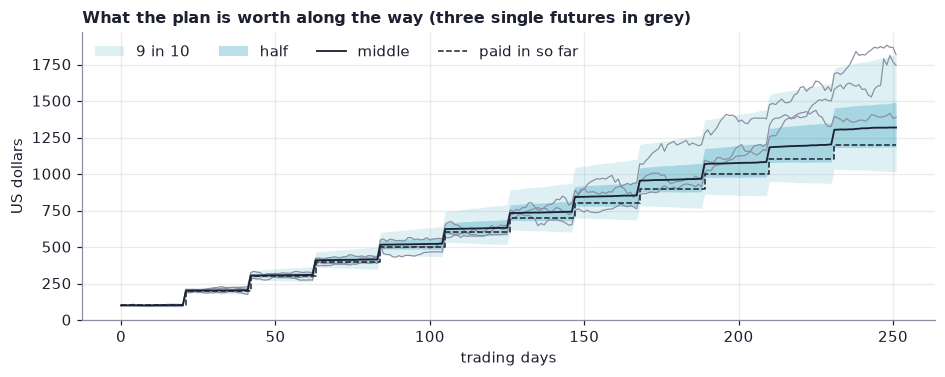

In [14]:
PLAN = {"stocks": 0.6, "bitcoin": 0.4}
AMOUNT, EVERY, PURCHASES = 100.0, 21, 12  # every 21 trading days is about a month
plan_returns = panel.returns[[OF_KIND[kind].symbol for kind in PLAN]].dropna()
plan_matrix = plan_returns.to_numpy()
plan_weights = np.array(list(PLAN.values()))
sessions = EVERY * PURCHASES
result = paying_in.run(plan_matrix, plan_weights, AMOUNT, EVERY, PURCHASES)
print(f"{len(plan_returns):,} trading days of prices, from {plan_returns.index[0].date()}")
print(f"the plan: {PURCHASES} purchases of ${AMOUNT:,.0f}, ${result.paid_in:,.0f} in all, {paying_in.DEFAULT_PATHS:,} futures")

rng = np.random.default_rng(1)
picked = ahead.sample_days(len(plan_matrix), sessions, 3, ahead.BLOCK, rng)
three, _ = paying_in.run_plan(plan_matrix[picked], plan_weights, AMOUNT, EVERY, PURCHASES)
span = range(sessions)
fig, ax = plt.subplots(figsize=(10, 3.4))
ax.fill_between(span, result.fan["0.05"], result.fan["0.95"], color=ACCENT, alpha=0.14, lw=0, label="9 in 10")
ax.fill_between(span, result.fan["0.25"], result.fan["0.75"], color=ACCENT, alpha=0.3, lw=0, label="half")
for path in three:
    ax.plot(path, color=MUTED, lw=0.8)
ax.plot(span, result.fan["0.5"], color=INK, lw=1.2, label="middle")
ax.step(span, result.paid_in_path, where="post", color=INK, ls="--", lw=1, label="paid in so far")
ax.set(title="What the plan is worth along the way (three single futures in grey)", xlabel="trading days", ylabel="US dollars")
ax.legend(loc="upper left", ncol=4);

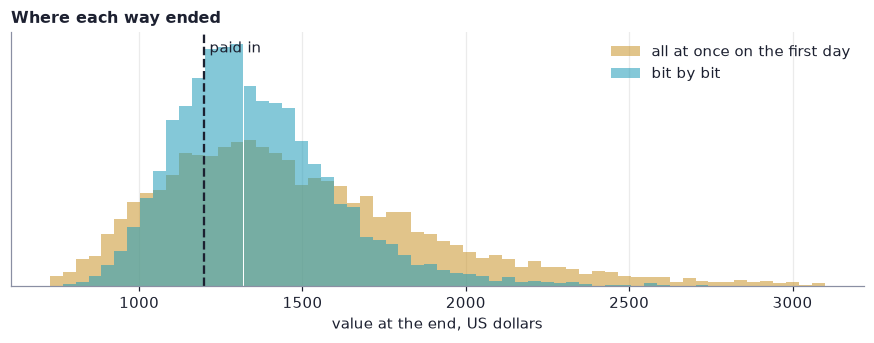

In [15]:
plan_ends, once_ends = (paths[:, -1] for paths in paying_in.simulate(plan_matrix, plan_weights, AMOUNT, EVERY, PURCHASES))
edges = np.linspace(*np.quantile(np.concatenate([plan_ends, once_ends]), [0.002, 0.995]), 61)
fig, ax = plt.subplots(figsize=(10, 3))
ax.hist(once_ends, bins=edges, alpha=0.55, color="#c9952b", label="all at once on the first day")
ax.hist(plan_ends, bins=edges, alpha=0.55, color=ACCENT, label="bit by bit")
ax.axvline(result.paid_in, color=INK, ls="--")
ax.text(result.paid_in, ax.get_ylim()[1] * 0.92, " paid in")
ax.set(title="Where each way ended", xlabel="value at the end, US dollars", yticks=[])
ax.legend();

In [16]:
ends = pd.DataFrame(
    {
        "bit by bit": {**result.plan.quantiles, "below": result.plan.below_paid_in * 100},
        "all at once": {**result.at_once.quantiles, "below": result.at_once.below_paid_in * 100},
    }
).rename(
    index={
        "0.05": "a bad outcome (1 in 20), $",
        "0.25": "lower quarter, $",
        "0.5": "middle, $",
        "0.75": "upper quarter, $",
        "0.95": "a good outcome (1 in 20), $",
        "below": "ends below what was paid in, % chance",
    }
)
print(f"bit by bit ended with more in {result.plan_ahead:.0%} of the futures")
ends.round(0)

bit by bit ended with more in 32% of the futures


,bit by bit,all at once
"a bad outcome (1 in 20), $","1,016.00",934.00
"lower quarter, $","1,184.00","1,182.00"
"middle, $","1,318.00","1,409.00"
"upper quarter, $","1,491.00","1,712.00"
"a good outcome (1 in 20), $","1,809.00","2,357.00"
"ends below what was paid in, % chance",28.00,27.00


A trade, not a winner. **All at once is wider**: the money is in the market for the
whole year, so its good outcomes are better and its bad ones worse. **Bit by bit is
narrower**: on average half the money is still waiting, so less is at risk at any
moment, and the price is giving up growth when markets rise. The line printed above
is how often bit by bit ended ahead.

### How far can this be trusted?

The same check as step 4: simulate the plan **from the days before a past date
only**, run the real plan through the days that followed, and see whether it landed
inside the range. Starts are a full plan apart, so no two share a day.

In [17]:
rows = {}
for label, every, purchases in (
    ("3 months, monthly", 21, 3),
    ("6 months, monthly", 21, 6),
    ("1 year, monthly", 21, 12),
    ("1 year, weekly", 5, 50),
    ("2 years, monthly", 21, 24),
):
    found = paying_in.coverage(paying_in.backtest(plan_matrix, plan_weights, every, purchases))
    rows[label] = {"past cases": found[0].n, **{f"{c.level:.0%} range held": f"{c.inside} of {c.n}" for c in found}}
pd.DataFrame(rows).T

,past cases,50% range held,80% range held,95% range held
"3 months, monthly",18,10 of 18,13 of 18,17 of 18
"6 months, monthly",9,4 of 9,7 of 9,8 of 9
"1 year, monthly",4,1 of 4,2 of 4,3 of 4
"1 year, weekly",4,1 of 4,2 of 4,3 of 4
"2 years, monthly",2,2 of 2,2 of 2,2 of 2


In [18]:
records = paying_in.backtest(plan_matrix, plan_weights, EVERY, PURCHASES)
tampered = plan_matrix.copy()
cut = len(plan_matrix) * 2 // 3
tampered[cut:] = 0.3
again = paying_in.backtest(tampered, plan_weights, EVERY, PURCHASES)
same = [one.bounds == other.bounds for one, other in zip(records, again) if one.origin <= cut]
assert all(same)
print(f"{len(same)} past ranges are identical after rewriting every day from row {cut} on")

3 past ranges are identical after rewriting every day from row 963 on


**There are very few cases for the long plans.** Only a handful of separate one-year
stretches fit in the stored prices, so this check can catch a method that is badly
wrong and cannot confirm one that is right. The app caps a plan at two years and says
how many stretches there were.

## What to take from this

- Look at the share of the risk, not the share of the money.
- The 30-day range held more often than it says (the count is in the chart title of
  step 4), which is within what luck allows on that many cases and on the wide side.
  It is no more accurate than a bell curve on this data. It is kept for the dips on
  the way, not for accuracy.
- Everything is drawn from the past few years. A future unlike anything in them is
  not in any range here.
- Paying in bit by bit lowers what is at risk early on. Ways of timing the purchases
  within a month were tested separately and paid slightly more, not less
  (`07_what_we_tested`).
- Trading costs and taxes are left out, and a purchase is assumed to happen at the
  day's closing price.
- A holding with a short price record cannot be drawn from. In the app its risk is
  estimated from the days it has and the screen says so.